## PART 1: IMPORT LIBRARIES AND SETUP¶

In [1]:
# PART 1: IMPORT LIBRARIES AND SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
## Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

## PART 2: LOAD AND EXPLORE DATA

In [2]:
import pandas as pd
# Load data
df = pd.read_csv('Supplemental Drone Telemetry Data - Drone Operations Log _test11.csv', 
                 on_bad_lines='skip')
df

,Drone ID,Application,Drone Size,Drone Model,Manufacturer,Propeller Count,Max Carry Weight (kg),Actual Carry Weight (kg),Payload Type,Payload Description,Altitude (meters),Flight Duration (minutes),Dstance Flown (km),Operator ID,Flight Date,Battery Remaining (%),GPS Accuracy (meters),Wind Speed (m/s),Obstacles Encountered,Flight Status
0,D001,Package Delivery,Medium,FlyHigh 300,AeroCorp,4.0,5.0,4.7,Package,Small consumer goods,90.0,35.0,12.0,OP001,3/20/2025,22.0,4.8,8.1,Yes,Landed Unexpectedly
1,D002,Infrastructure Inspection,Large,Inspecta X,SkyView Inc.,6.0,15.0,14.2,"Camera, Sensor","High-resolution camera, thermal sensor",150.0,55.0,18.0,OP002,3/21/2025,21.0,5.6,9.0,Yes,Landed Unexpectedly
2,D003,Agricultural Spraying,Large,CropMaster,AgriDrones,8.0,20.0,21.2,Liquid Tank,Pesticide solution,45.0,44.0,14.0,OP003,3/22/2025,19.0,6.1,8.7,Yes,Landed Unexpectedly
3,D004,Aerial Photography,Small,SnapShot Mini,PhotoFly,4.0,1.0,0.9,Camera,Lightweight action camera,100.0,28.0,7.0,OP004,3/23/2025,18.0,5.9,7.4,Yes,Landed Unexpectedly
4,D005,Surveillance,Medium,Watcher Pro,SecureTech,4.0,7.0,3.0,"Camera, Sensor","Infrared camera, motion detection sensor",100.0,72.0,12.0,OP005,3/24/2025,28.0,3.9,6.1,Yes,Landed Unexpectedly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,D819,Package Delivery,Small,SwiftWing,DeliveryNow,4.0,2.0,1.5,Package,Gift,71.0,19.0,6.5,OP011,3/8/2026,92.0,1.5,2.4,No,Completed
552,D749,Package Delivery,Medium,FlyHigh 300,AeroCorp,4.0,5.0,2.8,Package,Small items,69.0,25.0,7.5,OP015,9/28/2026,32.0,1.9,8.0,Yes,Landed Unexpectedly
553,D750,Aerial Photography,Small,SnapShot Mini,PhotoFly,4.0,1.0,0.5,Camera,Wide-angle lens,83.0,21.0,6.2,OP004,9/29/2026,96.0,1.3,2.4,No,Completed
554,D751,Agricultural Spraying,Large,CropMaster,AgriDrones,8.0,20.0,19.9,Liquid Tank,Insecticide,33.0,31.0,10.2,OP003,9/30/2026,33.0,4.0,8.9,Yes,Landed Unexpectedly


In [4]:
# Fix column typo if exists
df.rename(columns={'Dstance Flown (km)': 'Distance Flown (km)'}, inplace=True)
# Basic info
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
# Data tyes and stats
print(df.dtypes)
print(df.describe())
# Check missing values
print(df.isnull().sum())

Shape: (556, 20)
Columns: ['Drone ID', 'Application', 'Drone Size', 'Drone Model', 'Manufacturer', 'Propeller Count', 'Max Carry Weight (kg)', 'Actual Carry Weight (kg)', 'Payload Type', 'Payload Description', 'Altitude (meters)', 'Flight Duration (minutes)', 'Distance Flown (km)', 'Operator ID', 'Flight Date', 'Battery Remaining (%)', 'GPS Accuracy (meters)', 'Wind Speed (m/s)', 'Obstacles Encountered', 'Flight Status']
Drone ID                      object
Application                   object
Drone Size                    object
Drone Model                   object
Manufacturer                  object
Propeller Count              float64
Max Carry Weight (kg)        float64
Actual Carry Weight (kg)     float64
Payload Type                  object
Payload Description           object
Altitude (meters)            float64
Flight Duration (minutes)    float64
Distance Flown (km)          float64
Operator ID                   object
Flight Date                   object
Battery Remaining (%

## PART 3: DATA CLEANING

In [5]:
import numpy as np
print("Data Cleaning")
# Handle missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if not df[col].mode().empty:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle outliers: clip numeric columns using IQR
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Final check
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Data Cleaning
Missing values: 0
Dataset shape: (540, 20)


C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2682239373.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


## part4: Feature Engineering

In [6]:
# Convert 'Obstacles Encountered' to numeric
if 'Obstacles Encountered' in df.columns:
    df['Obstacles Encountered'] = df['Obstacles Encountered'].map({'Yes': 1, 'No': 0})

# Keep original 'Flight Status' for reference
if 'Flight Status' in df.columns:
    df['Flight Status_original'] = df['Flight Status']

# Columns overview
print(df[['Obstacles Encountered', 'Flight Status_original']].head())

   Obstacles Encountered Flight Status_original
0                      1    Landed Unexpectedly
1                      1    Landed Unexpectedly
2                      1    Landed Unexpectedly
3                      1    Landed Unexpectedly
4                      1    Landed Unexpectedly


In [7]:
df

,Drone ID,Application,Drone Size,Drone Model,Manufacturer,Propeller Count,Max Carry Weight (kg),Actual Carry Weight (kg),Payload Type,Payload Description,...,Flight Duration (minutes),Distance Flown (km),Operator ID,Flight Date,Battery Remaining (%),GPS Accuracy (meters),Wind Speed (m/s),Obstacles Encountered,Flight Status,Flight Status_original
0,D001,Package Delivery,Medium,FlyHigh 300,AeroCorp,4.0,5.0,4.7,Package,Small consumer goods,...,35.0,12.0,OP001,3/20/2025,22.0,4.8,8.1,1,Landed Unexpectedly,Landed Unexpectedly
1,D002,Infrastructure Inspection,Large,Inspecta X,SkyView Inc.,6.0,15.0,14.2,"Camera, Sensor","High-resolution camera, thermal sensor",...,55.0,18.0,OP002,3/21/2025,21.0,5.6,9.0,1,Landed Unexpectedly,Landed Unexpectedly
2,D003,Agricultural Spraying,Large,CropMaster,AgriDrones,8.0,20.0,14.9,Liquid Tank,Pesticide solution,...,44.0,14.0,OP003,3/22/2025,19.0,5.9,8.7,1,Landed Unexpectedly,Landed Unexpectedly
3,D004,Aerial Photography,Small,SnapShot Mini,PhotoFly,4.0,1.0,0.9,Camera,Lightweight action camera,...,28.0,7.0,OP004,3/23/2025,18.0,5.9,7.4,1,Landed Unexpectedly,Landed Unexpectedly
4,D005,Surveillance,Medium,Watcher Pro,SecureTech,4.0,7.0,3.0,"Camera, Sensor","Infrared camera, motion detection sensor",...,65.0,12.0,OP005,3/24/2025,28.0,3.9,6.1,1,Landed Unexpectedly,Landed Unexpectedly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,D819,Package Delivery,Small,SwiftWing,DeliveryNow,4.0,2.0,1.5,Package,Gift,...,19.0,6.5,OP011,3/8/2026,92.0,1.5,2.4,0,Completed,Completed
552,D749,Package Delivery,Medium,FlyHigh 300,AeroCorp,4.0,5.0,2.8,Package,Small items,...,25.0,7.5,OP015,9/28/2026,32.0,1.9,8.0,1,Landed Unexpectedly,Landed Unexpectedly
553,D750,Aerial Photography,Small,SnapShot Mini,PhotoFly,4.0,1.0,0.5,Camera,Wide-angle lens,...,21.0,6.2,OP004,9/29/2026,96.0,1.3,2.4,0,Completed,Completed
554,D751,Agricultural Spraying,Large,CropMaster,AgriDrones,8.0,20.0,14.9,Liquid Tank,Insecticide,...,31.0,10.2,OP003,9/30/2026,33.0,4.0,8.9,1,Landed Unexpectedly,Landed Unexpectedly


## PART 5: ENCODE CATEGORICAL VARIABLES

In [8]:
from sklearn.preprocessing import LabelEncoder

# Define target column
target_col = 'Flight Status'
target_col_original = 'Flight Status_original' if 'Flight Status_original' in df.columns else target_col

# Encode target column
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col_original].astype(str))

# Encode other categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col != target_col_original:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
df

,Drone ID,Application,Drone Size,Drone Model,Manufacturer,Propeller Count,Max Carry Weight (kg),Actual Carry Weight (kg),Payload Type,Payload Description,...,Flight Duration (minutes),Distance Flown (km),Operator ID,Flight Date,Battery Remaining (%),GPS Accuracy (meters),Wind Speed (m/s),Obstacles Encountered,Flight Status,Flight Status_original
0,2,11,2,8,0,4.0,5.0,4.7,10,93,...,35.0,12.0,1,179,22.0,4.8,8.1,1,1,Landed Unexpectedly
1,3,10,1,10,11,6.0,15.0,14.2,3,48,...,55.0,18.0,3,180,21.0,5.6,9.0,1,1,Landed Unexpectedly
2,4,1,1,4,1,8.0,20.0,14.9,9,85,...,44.0,14.0,4,181,19.0,5.9,8.7,1,1,Landed Unexpectedly
3,5,0,3,17,8,4.0,1.0,0.9,0,62,...,28.0,7.0,5,182,18.0,5.9,7.4,1,1,Landed Unexpectedly
4,6,18,2,24,10,4.0,7.0,3.0,3,57,...,65.0,12.0,6,183,28.0,3.9,6.1,1,1,Landed Unexpectedly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,533,11,3,20,2,4.0,2.0,1.5,10,34,...,19.0,6.5,12,199,92.0,1.5,2.4,0,0,Completed
552,529,11,2,8,0,4.0,5.0,2.8,10,96,...,25.0,7.5,15,383,32.0,1.9,8.0,1,1,Landed Unexpectedly
553,530,0,3,17,8,4.0,1.0,0.5,0,131,...,21.0,6.2,5,385,96.0,1.3,2.4,0,0,Completed
554,531,1,1,4,1,8.0,20.0,14.9,9,58,...,31.0,10.2,4,388,33.0,4.0,8.9,1,1,Landed Unexpectedly


## PART 6: EXPLORATORY DATA ANALYSIS (EDA)

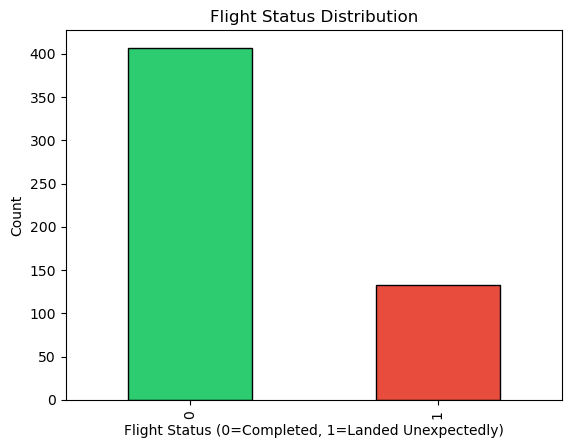

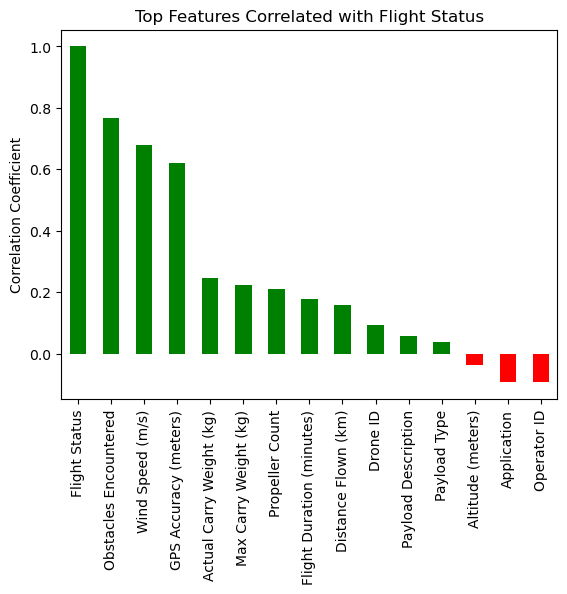

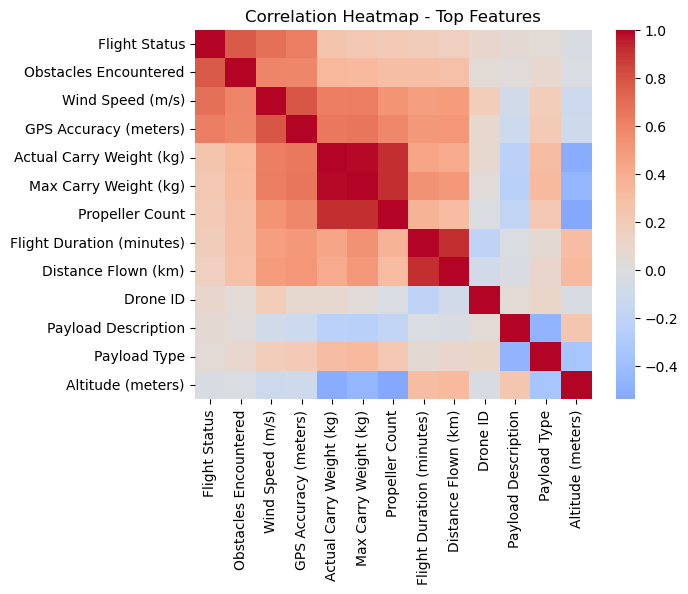

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure target column exists
target_col = 'Flight Status'

# 1️Target Distribution
if target_col in df.columns:
    df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
    plt.title('Flight Status Distribution')
    plt.xlabel('Flight Status (0=Completed, 1=Landed Unexpectedly)')
    plt.ylabel('Count')
    plt.show()

# 2️ Correlation Analysis
if target_col in df.columns:
    numeric_df = df.select_dtypes(include=[np.number])
    correlations = numeric_df.corr()[target_col].sort_values(ascending=False)
    correlations.head(15).plot(kind='bar', color=['green' if x>0 else 'red' for x in correlations.head(15)])
    plt.title('Top Features Correlated with Flight Status')
    plt.ylabel('Correlation Coefficient')
    plt.show()
    

# 3️ Correlation Heatmap
top_features = correlations.head(13).index.tolist()
if len(top_features) > 1:
    corr_subset = numeric_df[top_features].corr()
    sns.heatmap(corr_subset, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap - Top Features')
    plt.show()

Univariate Analysis: Attribute Distributions


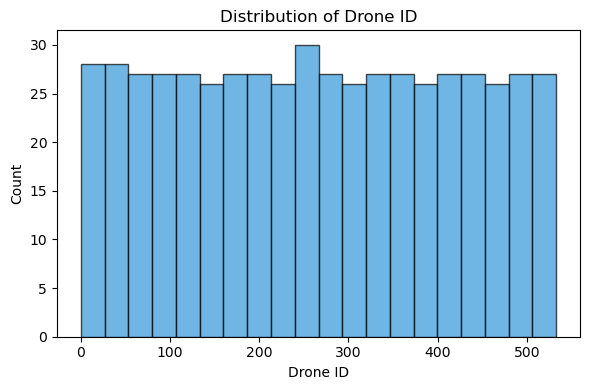

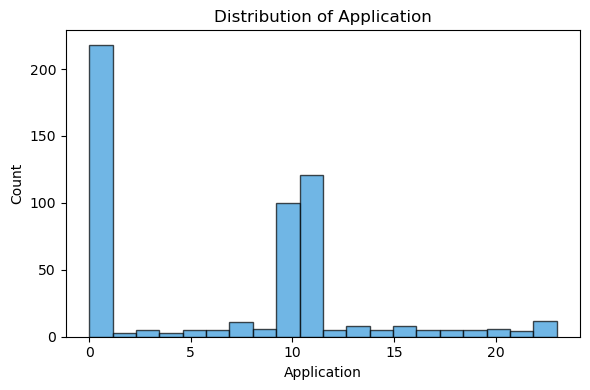

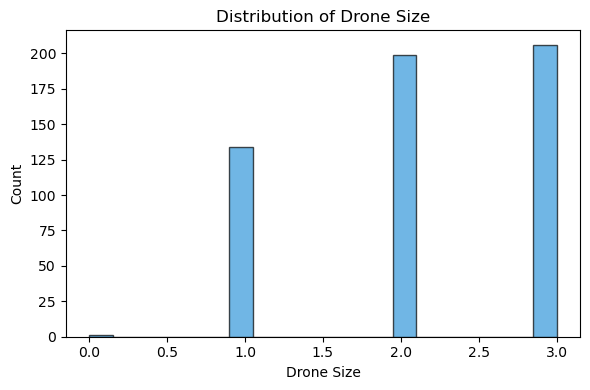

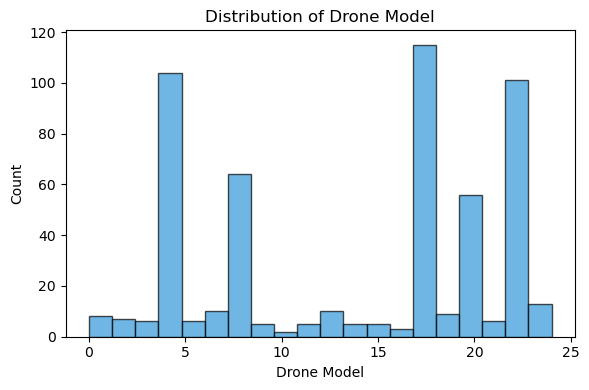

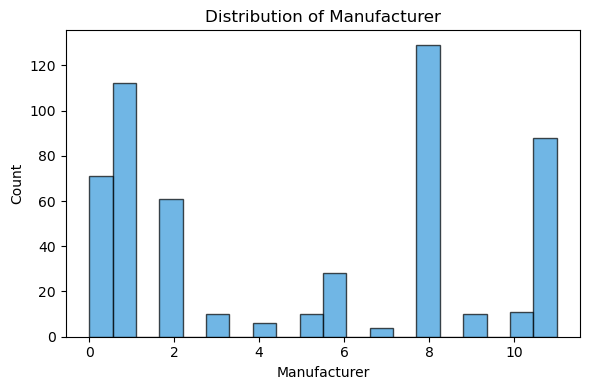

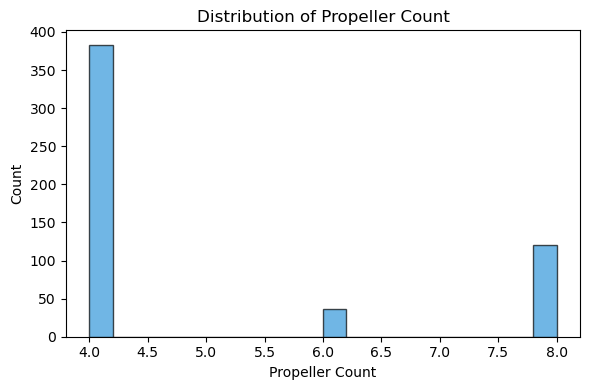

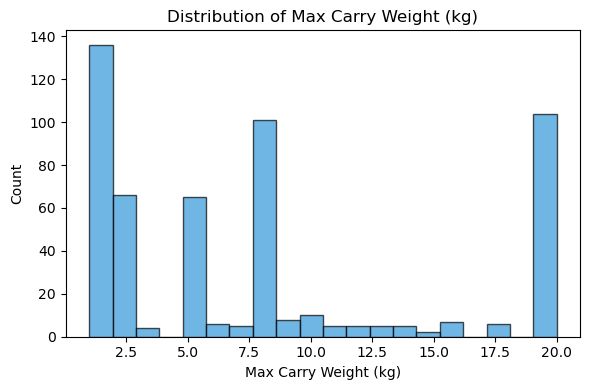

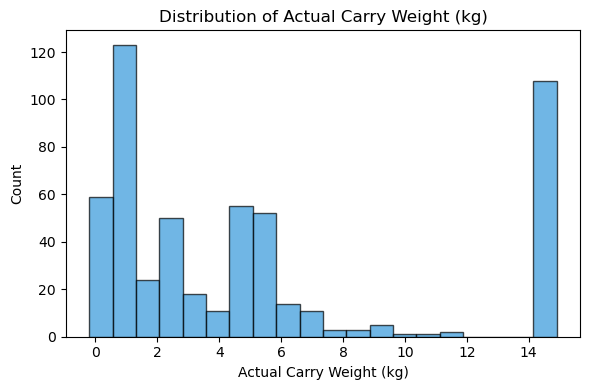

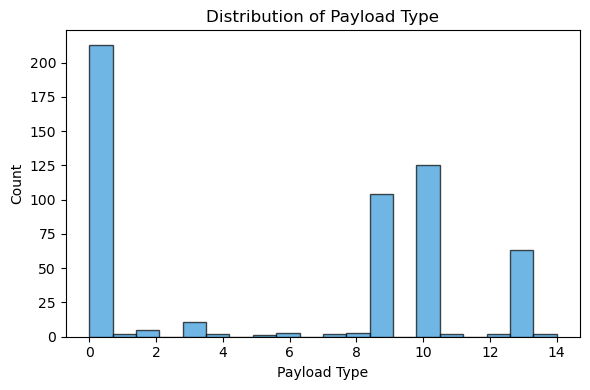

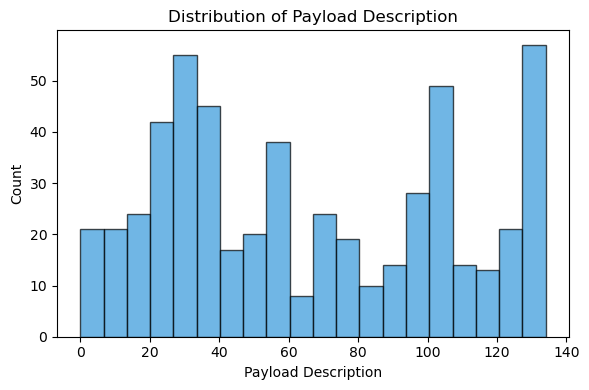

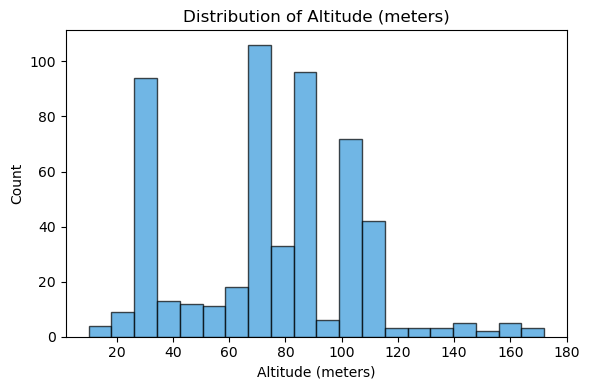

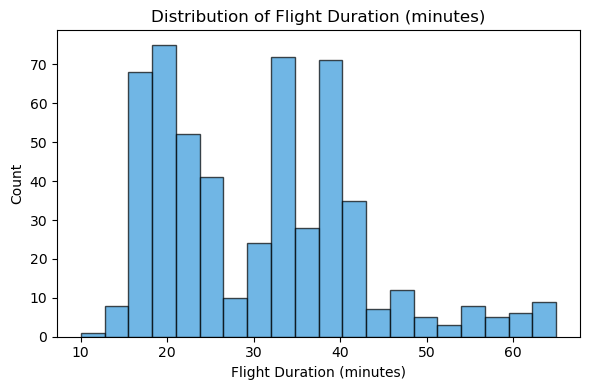

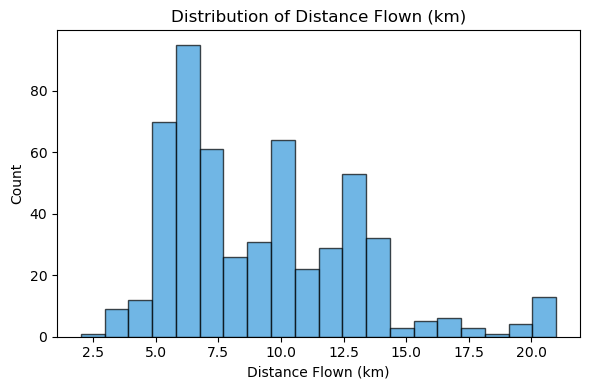

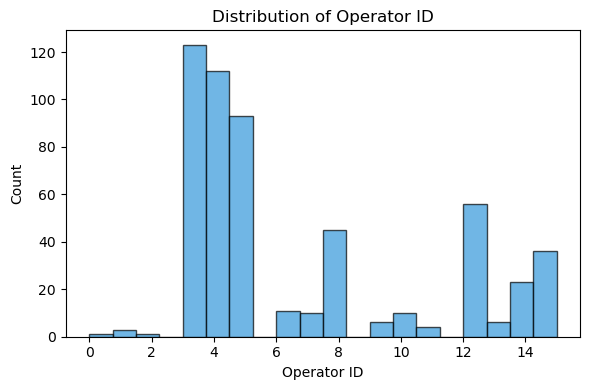

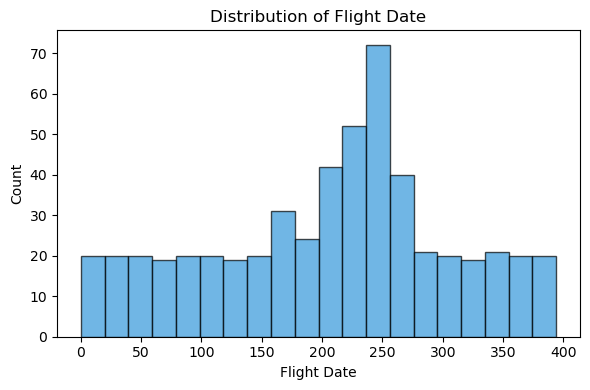

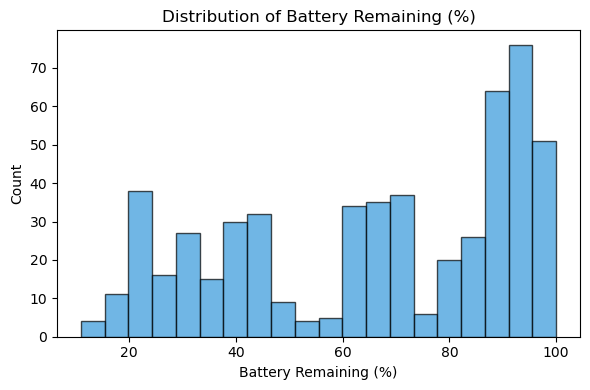

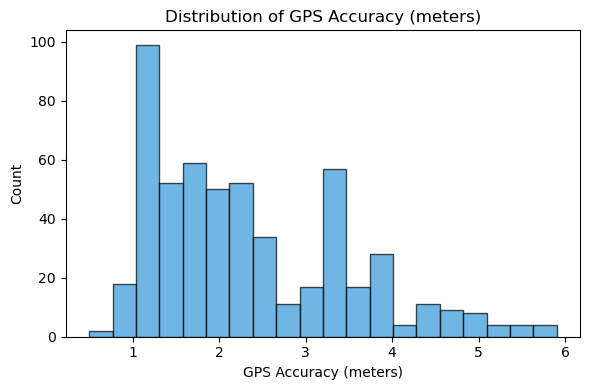

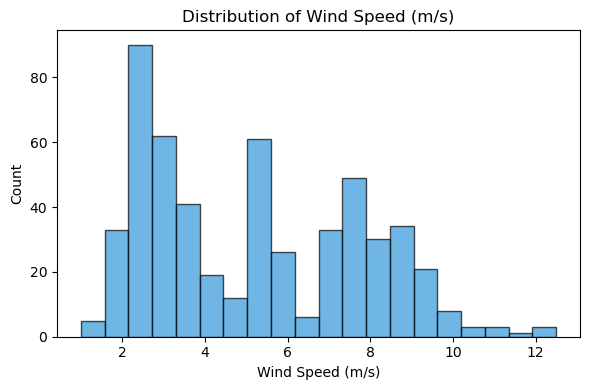

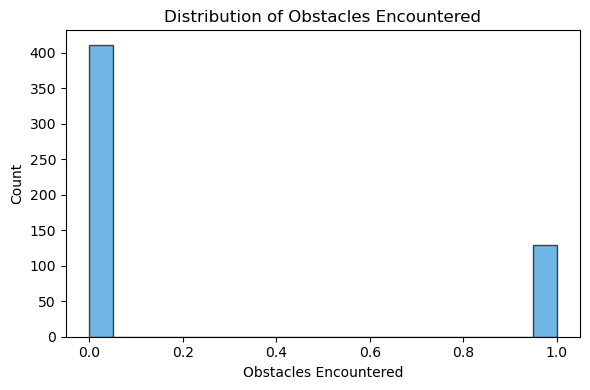

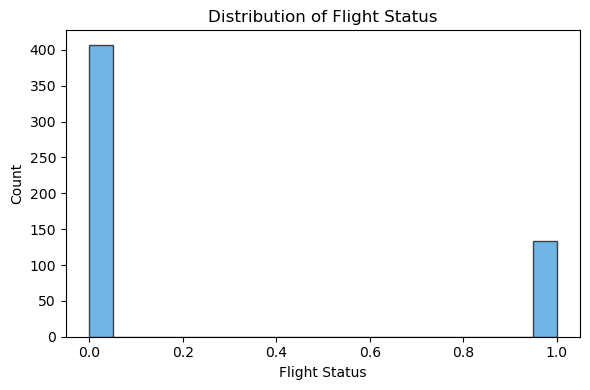

In [10]:
# Ensure target column
target_col = 'Flight Status'
# 1️ Univariate Analysis
print("Univariate Analysis: Attribute Distributions")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


Bivariate Analysis: Feature vs Target


C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


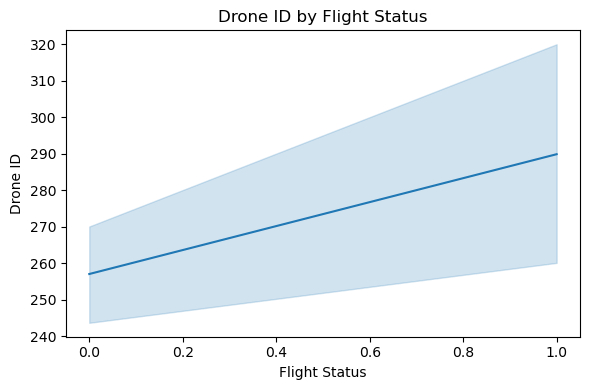

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


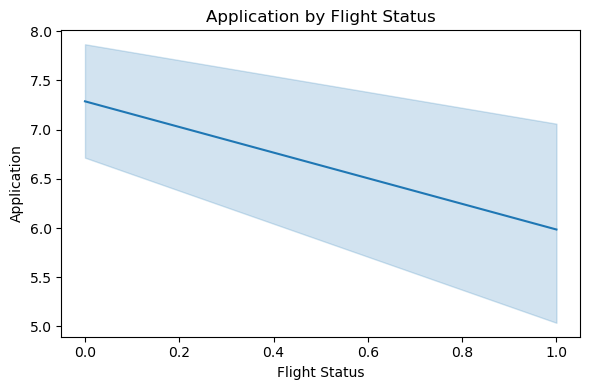

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


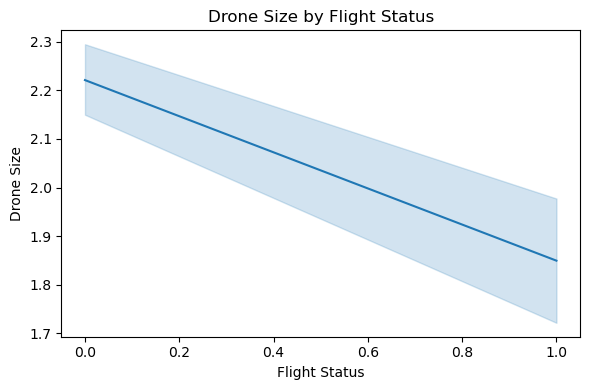

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


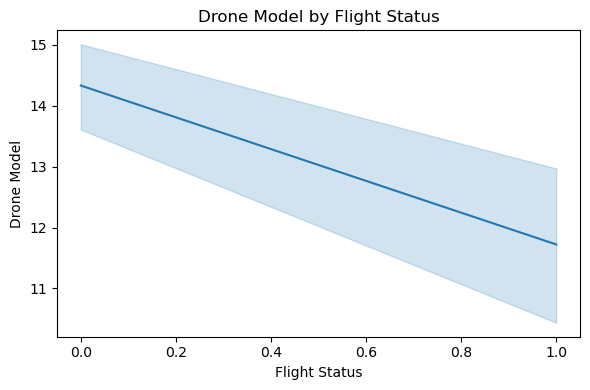

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


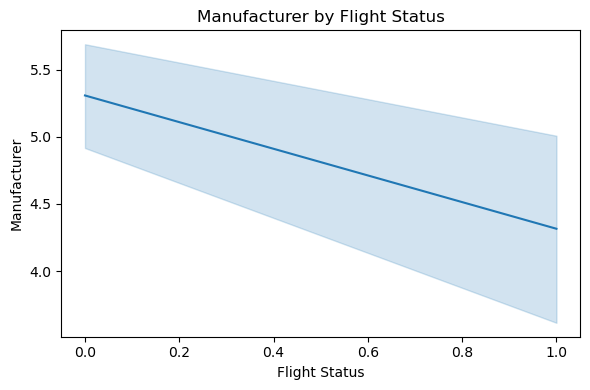

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


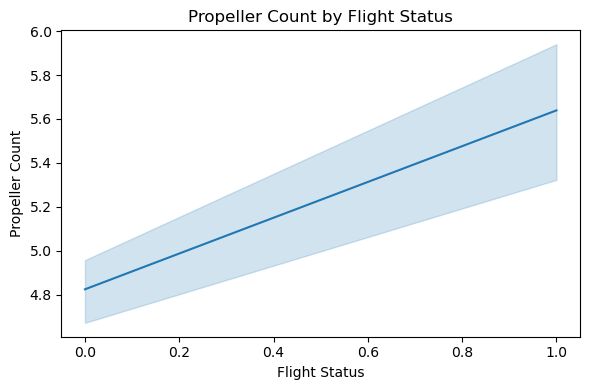

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


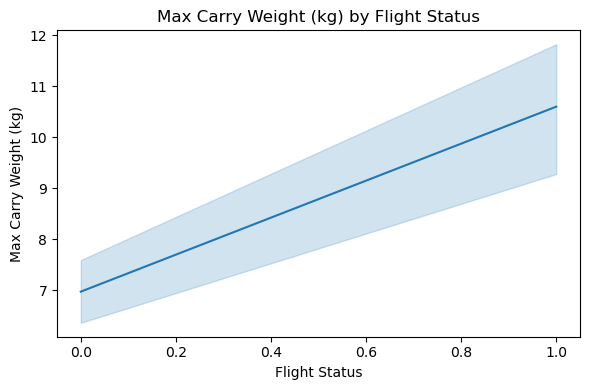

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


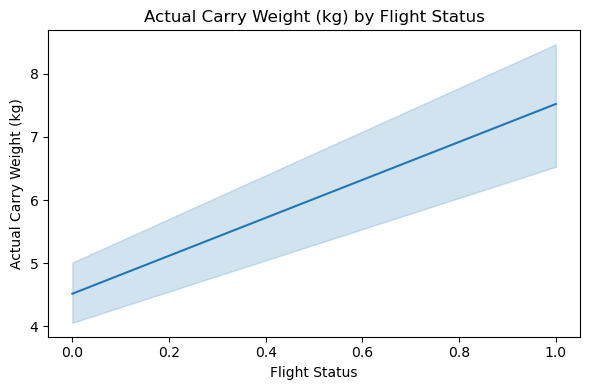

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


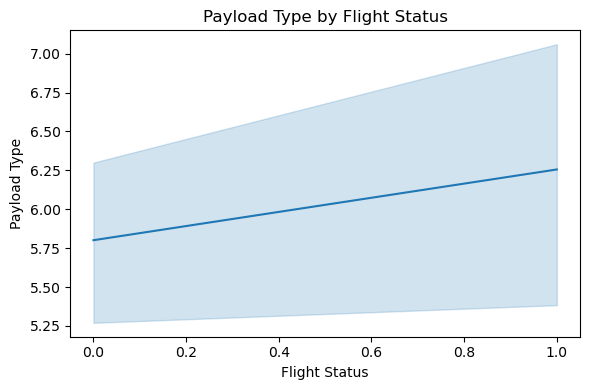

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


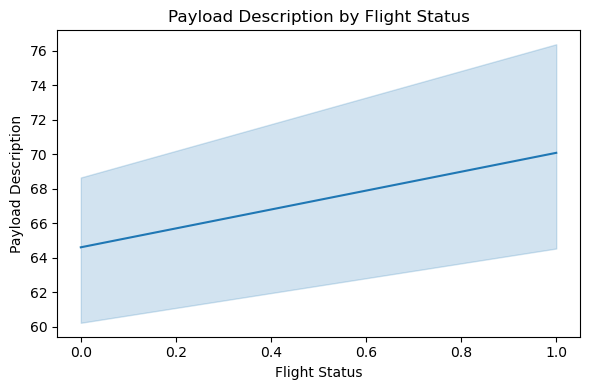

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


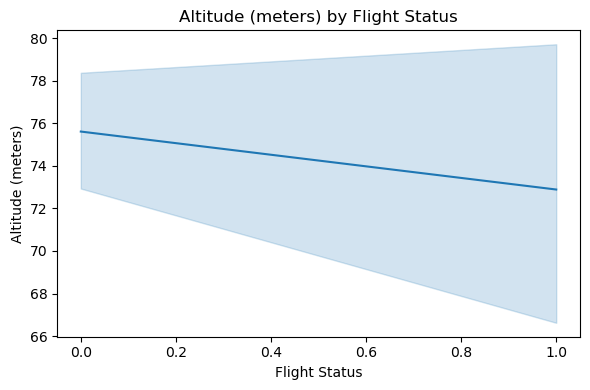

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


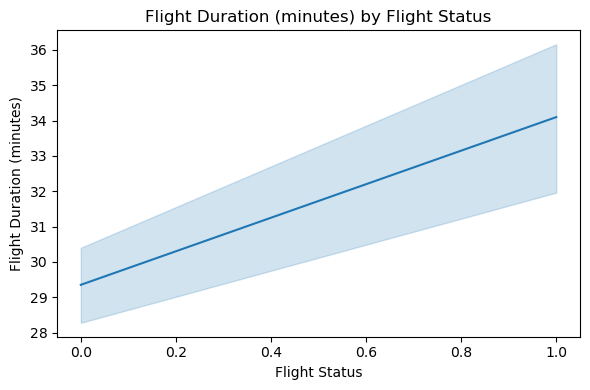

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


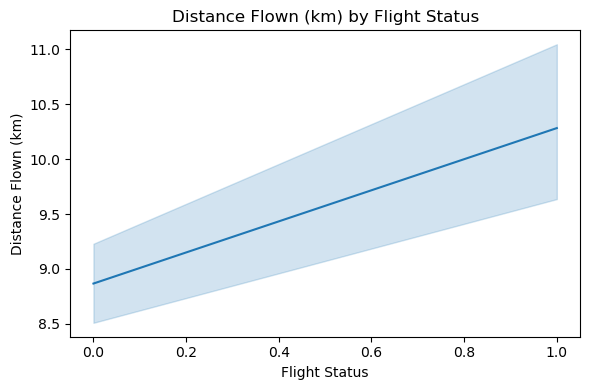

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


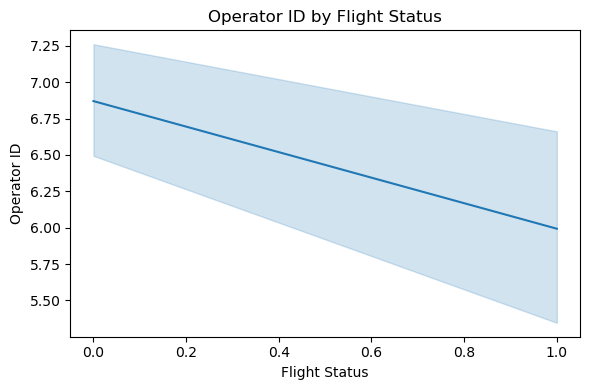

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


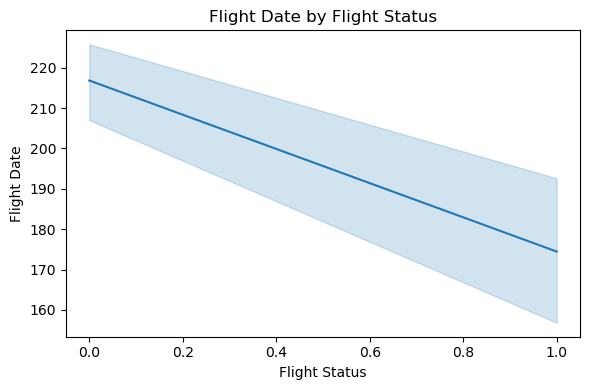

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


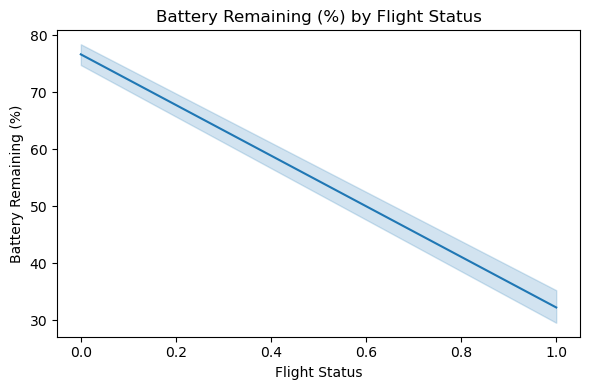

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


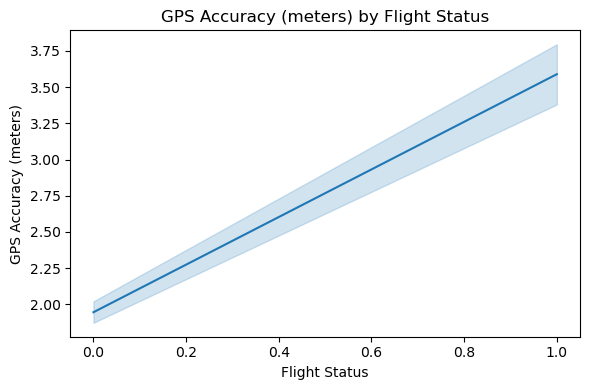

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


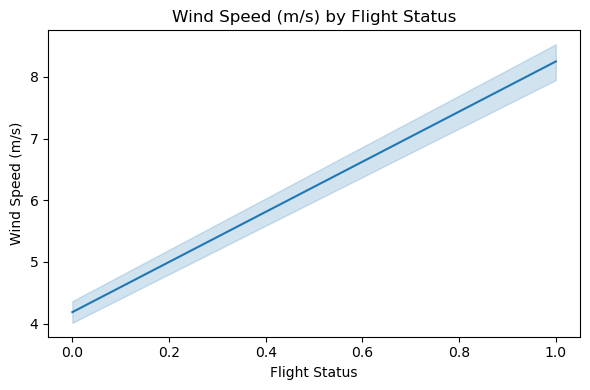

C:\Users\eys20\AppData\Local\Temp\ipykernel_14324\2113912215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=target_col, y=col, data=df, palette='Set2')


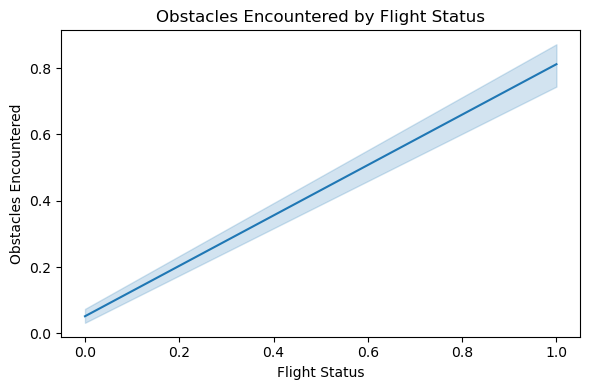

In [11]:
# =========================
# 2️⃣ Bivariate Analysis
# =========================
print("Bivariate Analysis: Feature vs Target")

for col in numeric_cols:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.lineplot(x=target_col, y=col, data=df, palette='Set2')
        plt.title(f'{col} by {target_col}')
        plt.tight_layout()
        plt.show()

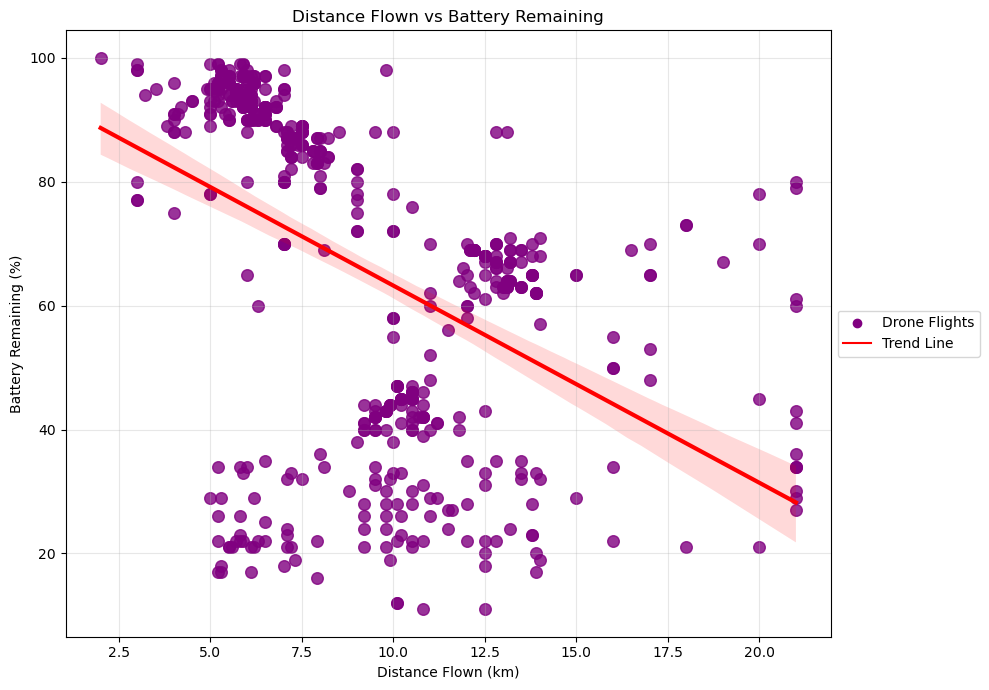

In [12]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Distance Flown (km)"],
   y=df["Battery Remaining (%)"],
   scatter_kws={"color": "purple", "s": 70},
   line_kws={"color": "red", "linewidth": 3}
)
plt.title("Distance Flown vs Battery Remaining")
plt.xlabel("Distance Flown (km)")
plt.ylabel("Battery Remaining (%)")
plt.scatter([], [], color="purple", label="Drone Flights")
plt.plot([], [], color="red", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

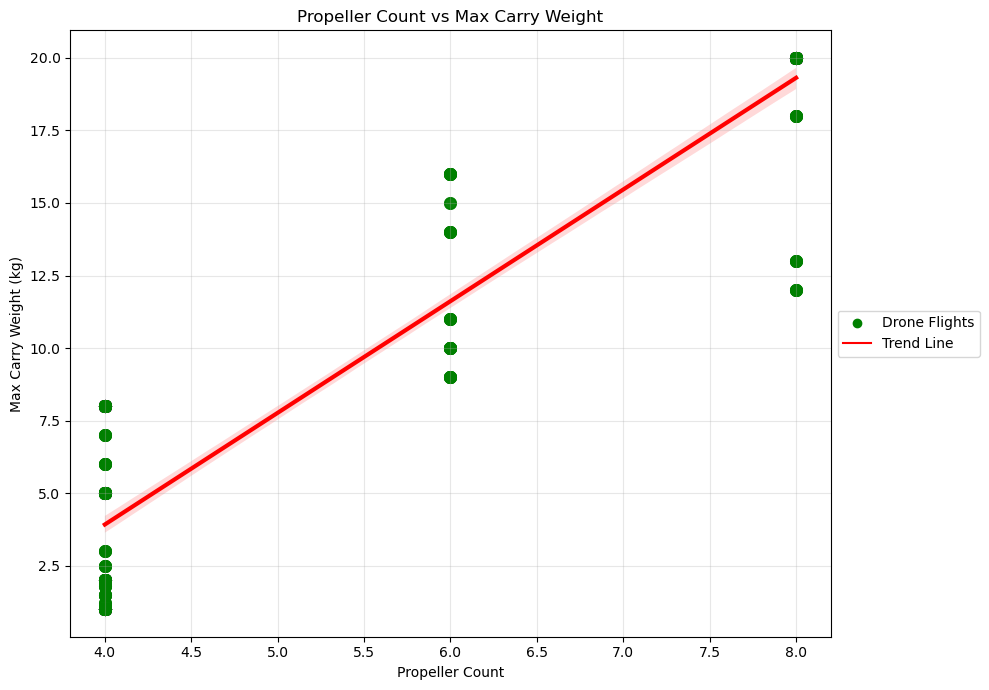

In [13]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Propeller Count"],
   y=df["Max Carry Weight (kg)"],
   scatter_kws={"color":"green","s":70},
   line_kws={"color":"red","linewidth":3}
)
plt.title("Propeller Count vs Max Carry Weight")
plt.xlabel("Propeller Count")
plt.ylabel("Max Carry Weight (kg)")
plt.scatter([], [], color="green", label="Drone Flights")
plt.plot([], [], color="red", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

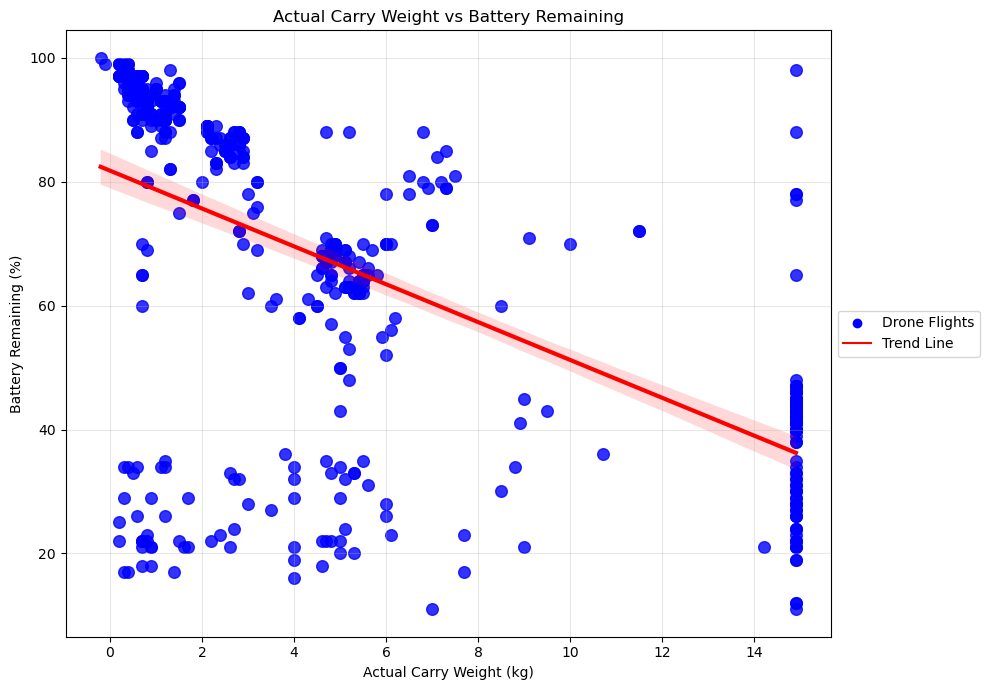

In [14]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Actual Carry Weight (kg)"],
   y=df["Battery Remaining (%)"],
   scatter_kws={"color":"blue","s":70},
   line_kws={"color":"red","linewidth":3}
)
plt.title("Actual Carry Weight vs Battery Remaining")
plt.xlabel("Actual Carry Weight (kg)")
plt.ylabel("Battery Remaining (%)")
plt.scatter([], [], color="blue", label="Drone Flights")
plt.plot([], [], color="red", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

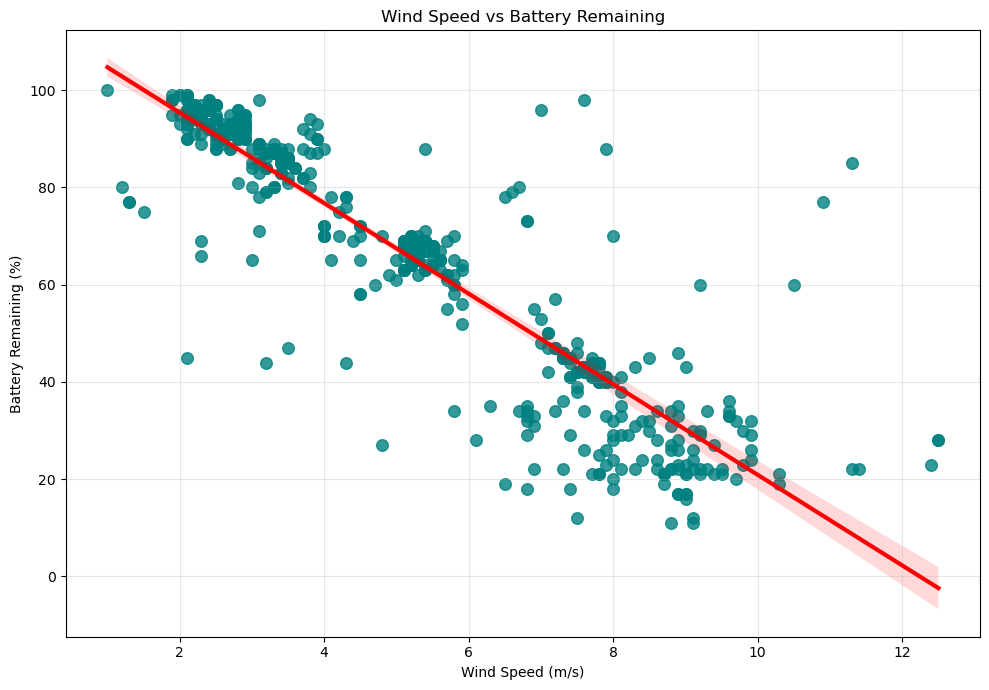

In [15]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Wind Speed (m/s)"],
   y=df["Battery Remaining (%)"],
   scatter_kws={"color":"teal","s":70},
   line_kws={"color":"red","linewidth":3}
)
plt.title("Wind Speed vs Battery Remaining")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Battery Remaining (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

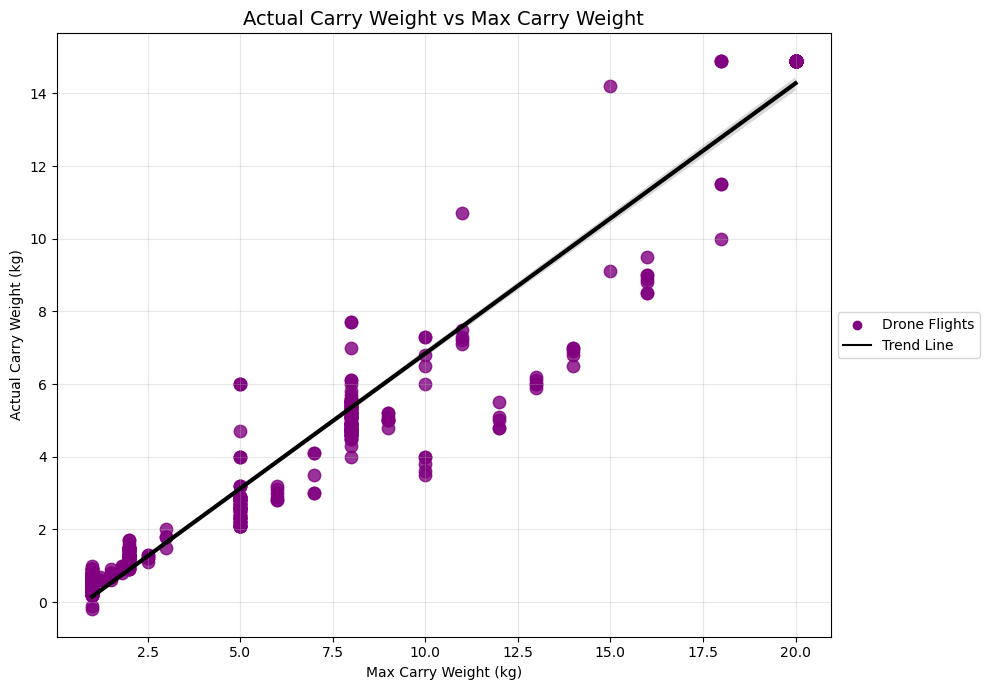

In [16]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Max Carry Weight (kg)"],
   y=df["Actual Carry Weight (kg)"],
   scatter_kws={"color":"purple","s":80,"alpha":0.8},
   line_kws={"color":"black","linewidth":3}
)
plt.title("Actual Carry Weight vs Max Carry Weight", fontsize=14)
plt.xlabel("Max Carry Weight (kg)")
plt.ylabel("Actual Carry Weight (kg)")
plt.scatter([], [], color="purple", label="Drone Flights")
plt.plot([], [], color="black", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

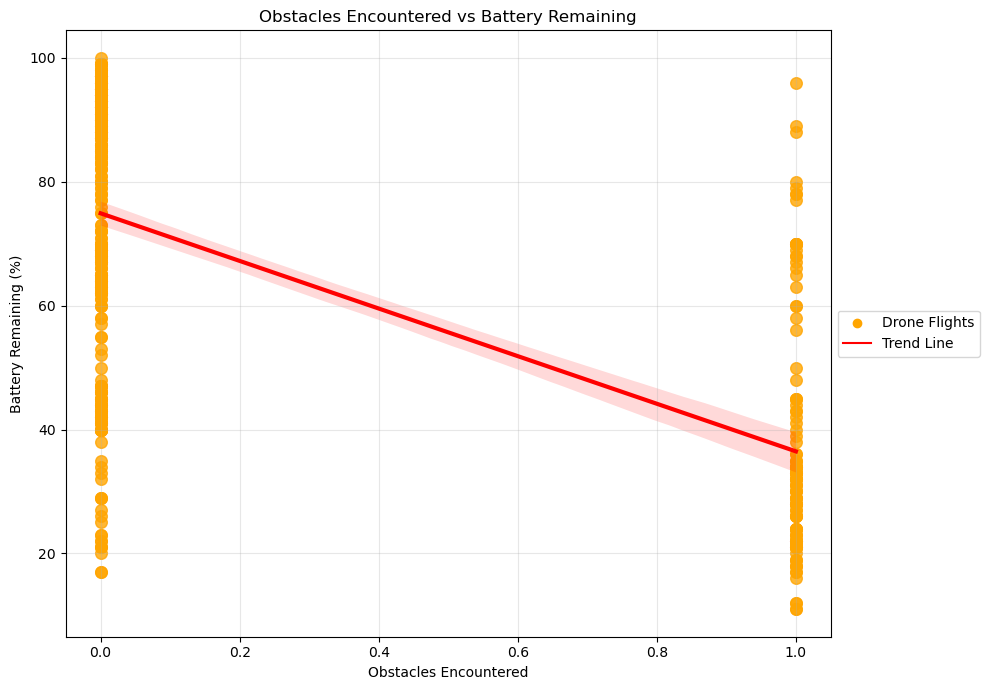

In [17]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["Obstacles Encountered"],
   y=df["Battery Remaining (%)"],
   scatter_kws={"color":"orange","s":70},
   line_kws={"color":"red","linewidth":3}
)
plt.title("Obstacles Encountered vs Battery Remaining")
plt.xlabel("Obstacles Encountered")
plt.ylabel("Battery Remaining (%)")
plt.scatter([], [], color="orange", label="Drone Flights")
plt.plot([], [], color="red", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

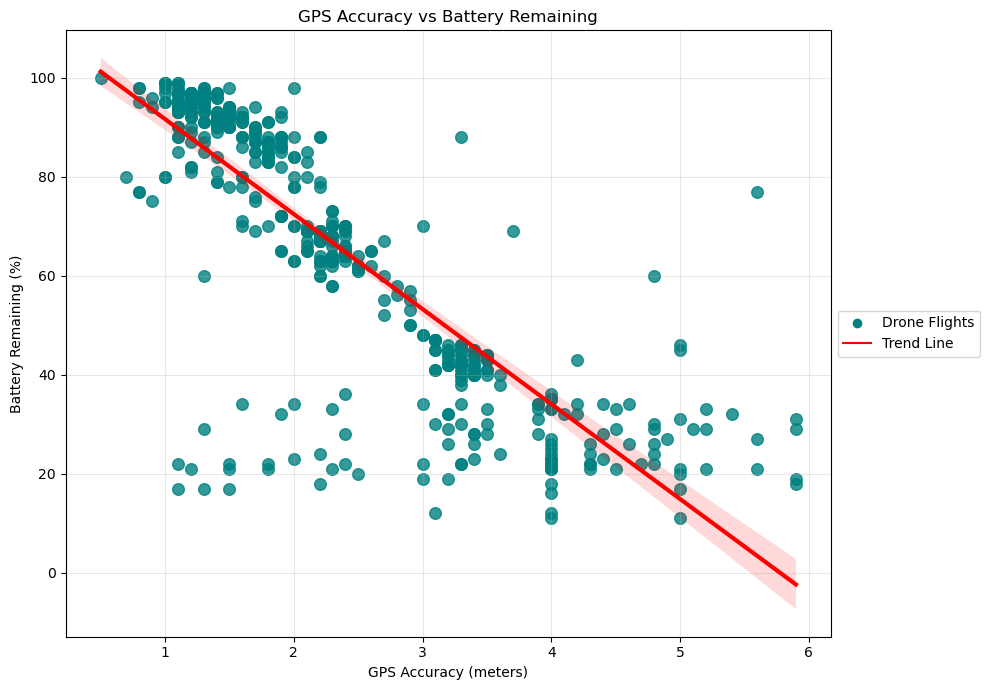

In [18]:
plt.figure(figsize=(10,7))
sns.regplot(
   x=df["GPS Accuracy (meters)"],
   y=df["Battery Remaining (%)"],
   scatter_kws={"color":"teal","s":70},
   line_kws={"color":"red","linewidth":3}
)
plt.title("GPS Accuracy vs Battery Remaining")
plt.xlabel("GPS Accuracy (meters)")
plt.ylabel("Battery Remaining (%)")
plt.scatter([], [], color="teal", label="Drone Flights")
plt.plot([], [], color="red", label="Trend Line")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


📈 Feature Correlation
Obstacles Encountered        0.768366
Wind Speed (m/s)             0.680805
GPS Accuracy (meters)        0.621753
Actual Carry Weight (kg)     0.245822
Max Carry Weight (kg)        0.224193
Propeller Count              0.210336
Flight Duration (minutes)    0.176664
Distance Flown (km)          0.158617
Drone ID                     0.091685
Payload Description          0.058040
Payload Type                 0.038215
Altitude (meters)           -0.038151
Application                 -0.091838
Operator ID                 -0.093921
Manufacturer                -0.104810
Drone Model                 -0.155441
Flight Date                 -0.183011
Drone Size                  -0.203244
Battery Remaining (%)       -0.723348
Name: Flight Status, dtype: float64


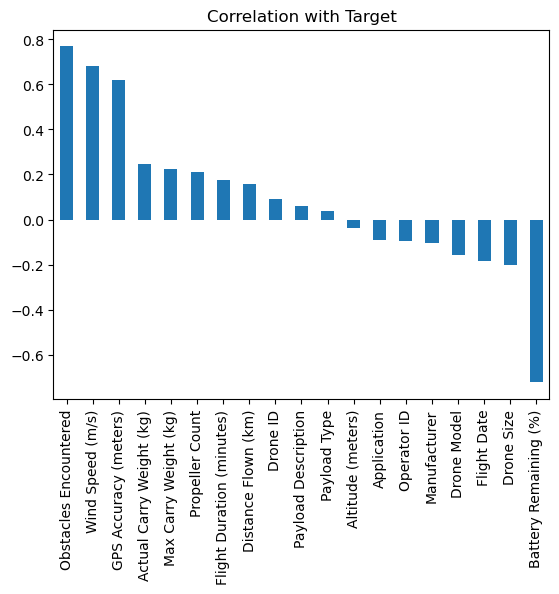

In [19]:
print("\n📈 Feature Correlation")

numeric_df = df.select_dtypes(include=[np.number])

if target_col in numeric_df.columns:
    corrs = numeric_df.corr()[target_col].drop(target_col).sort_values(ascending=False)
    print(corrs)

    corrs.plot(kind='bar')
    plt.title('Correlation with Target')
    plt.show()

## PART 7: PREPARE DATA FOR MODELING

In [20]:
# Selected features based on correlation with target
selected_features = [
    'Obstacles Encountered',
    'Battery Remaining (%)',
    'Wind Speed (m/s)',
    'GPS Accuracy (meters)',
    'Actual Carry Weight (kg)',
    'Max Carry Weight (kg)',
    'Propeller Count',
    'Drone Size',
    'Distance Flown (km)',
    'Drone Model',
    'Payload Type',
    'Application',
    'Altitude (meters)'
]
# Make sure all selected features exist in the dataframe
available_features = [f for f in selected_features if f in df.columns]
print(f" Using {len(available_features)} selected features")
print(f"Features: {available_features}")

# Prepare X and y
X = df[available_features]
y = df['Flight Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\n Data shape after SMOTE:")
print(f"   Training: {X_train_resampled.shape[0]} samples")
print(f"   Testing: {X_test_scaled.shape[0]} samples")


 Using 13 selected features
Features: ['Obstacles Encountered', 'Battery Remaining (%)', 'Wind Speed (m/s)', 'GPS Accuracy (meters)', 'Actual Carry Weight (kg)', 'Max Carry Weight (kg)', 'Propeller Count', 'Drone Size', 'Distance Flown (km)', 'Drone Model', 'Payload Type', 'Application', 'Altitude (meters)']

 Data shape after SMOTE:
   Training: 652 samples
   Testing: 108 samples


##  PART 8: TRAIN MODELS

In [22]:
# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

# Results dictionary
results = {}

# Train each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Model': model,
        'Predictions': y_pred
    }
    
    print(f" {name}")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1 Score: {f1:.4f}")


Training Logistic Regression...
✅ Logistic Regression
   Accuracy: 0.9537
   Precision: 0.8929
   Recall: 0.9259
   F1 Score: 0.9091

Training Random Forest...
✅ Random Forest
   Accuracy: 0.9815
   Precision: 0.9630
   Recall: 0.9630
   F1 Score: 0.9630

Training XGBoost...
✅ XGBoost
   Accuracy: 0.9537
   Precision: 0.8438
   Recall: 1.0000
   F1 Score: 0.9153

Training SVM...
✅ SVM
   Accuracy: 0.9444
   Precision: 0.8387
   Recall: 0.9630
   F1 Score: 0.8966


In [21]:
# ARTIFICIAL NEURAL NETWORK (ANN) (Fully Connected Layer )
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    
    print("Training Deep ANN (Keras)...")
    print('='*50)
    
    # Create Keras model
    keras_model = Sequential([
        Dense(64, activation='relu', input_dim=X_train_resampled.shape[1]),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    
    # Train model
    history = keras_model.fit(
        X_train_resampled, y_train_resampled,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Predict
    y_pred_keras = (keras_model.predict(X_test_scaled) > 0.5).astype(int)
    
    keras_accuracy = accuracy_score(y_test, y_pred_keras)
    keras_precision = precision_score(y_test, y_pred_keras)
    keras_recall = recall_score(y_test, y_pred_keras)
    keras_f1 = f1_score(y_test, y_pred_keras)
    
    results['ANN (Keras)'] = {
        'Accuracy': keras_accuracy,
        'Precision': keras_precision,
        'Recall': keras_recall,
        'F1 Score': keras_f1,
        'Model': keras_model,
        'Predictions': y_pred_keras,
        'History': history
    }
    
    print(f" ANN (Keras)")
    print(f"   Accuracy: {keras_accuracy:.4f}")
    print(f"   Precision: {keras_precision:.4f}")
    print(f"   Recall: {keras_recall:.4f}")
    print(f"   F1 Score: {keras_f1:.4f}")
    
except ImportError:
    print("TensorFlow not installed. Skipping Keras model.")
    print("To install: pip install tensorflow")


Training Deep ANN (Keras)...


C:\Users\eys20\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 ANN (Keras)
   Accuracy: 0.9815
   Precision: 1.0000
   Recall: 0.9259
   F1 Score: 0.9615


## PART 9: HYPERPARAMETER TUNING WITH GRIDSEARCHCV


In [ ]:
# P: HYPERPARAMETER TUNING WITH GRIDSEARCHCV 

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Define models with hyperparameter grids
models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 1.0]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.1, 1],
            'kernel': ['rbf', 'linear']
        }
    }
}  

# Results dictionary for tuned models
results_tuned = {}

print("="*60)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*60)

for name, config in models_params.items():
    print(f"\n{'='*50}")
    print(f"Tuning {name}...")
    print('='*50)
    
    # Create GridSearchCV object
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results_tuned[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Model': best_model,
        'Best Params': grid_search.best_params_,
        'Best CV Score': grid_search.best_score_,
        'Predictions': y_pred
    }
    
    print(f"\n {name} - Best Parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\n   Best CV F1 Score: {grid_search.best_score_:.4f}")
    print(f"   Test Set Performance:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1 Score: {f1:.4f}")


# ------------------------------
# PART 8.1: DEEP ANN (Keras) WITH HYPERPARAMETER TUNING
# ------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print(" DEEP ANN (Keras) - HYPERPARAMETER TUNING")
print("="*60)

# Define hyperparameters to test
param_grid = {
    'units_layer1': [32, 64, 128],
    'units_layer2': [16, 32, 64],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.01],
    'batch_size': [16, 32]
}

best_f1 = 0
best_params = {}
best_model = None
best_history = None

total_combinations = len(list(ParameterGrid(param_grid)))
print(f"Testing {total_combinations} different configurations...")

for i, params in enumerate(ParameterGrid(param_grid)):
    print(f"\nTesting configuration {i+1}/{total_combinations}")
    print(f"   Units Layer 1: {params['units_layer1']}, Units Layer 2: {params['units_layer2']}")
    print(f"   Dropout: {params['dropout_rate']}, LR: {params['learning_rate']}, Batch: {params['batch_size']}")
    
    # Create Keras model
    keras_model = Sequential([
        Dense(params['units_layer1'], activation='relu', input_dim=X_train_resampled.shape[1]),
        Dropout(params['dropout_rate']),
        Dense(params['units_layer2'], activation='relu'),
        Dropout(params['dropout_rate']),
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = Adam(learning_rate=params['learning_rate'])
    keras_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    # Train model
    history = keras_model.fit(
        X_train_resampled, y_train_resampled,
        validation_split=0.2,
        epochs=100,
        batch_size=params['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )
    
    # Predict
    y_pred_keras = (keras_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_keras)
    
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_model = keras_model
        best_history = history
        print(f" New best! F1 Score: {f1:.4f}")

# Train best model one more time (optional)
print("BEST ANN MODEL FOUND")
print(f"Best Parameters:")
print(f"   Units Layer 1: {best_params['units_layer1']}")
print(f"   Units Layer 2: {best_params['units_layer2']}")
print(f"   Dropout Rate: {best_params['dropout_rate']}")
print(f"   Learning Rate: {best_params['learning_rate']}")
print(f"   Batch Size: {best_params['batch_size']}")

# Final evaluation with best model
y_pred_best = (best_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

# Store results
results_tuned['ANN (Keras)'] = {
    'Accuracy': accuracy_best,
    'Precision': precision_best,
    'Recall': recall_best,
    'F1 Score': f1_best,
    'Model': best_model,
    'Best Params': best_params,
    'Predictions': y_pred_best,
    'History': best_history
}

print(f"\n ANN (Keras) - Best Model Performance:")
print(f"   Accuracy: {accuracy_best:.4f}")
print(f"   Precision: {precision_best:.4f}")
print(f"   Recall: {recall_best:.4f}")
print(f"   F1 Score: {f1_best:.4f}")



# ------------------------------
# PART 9: COMPARE ALL MODELS (Including ANN)
# ------------------------------

print("\n" + "="*60)
print(" PERFORMANCE COMPARISON (All Models After Tuning)")
print("="*60)

# Create comparison DataFrame
comparison_data = []
for name in results_tuned.keys():
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{results_tuned[name]['Accuracy']:.4f}",
        'Precision': f"{results_tuned[name]['Precision']:.4f}",
        'Recall': f"{results_tuned[name]['Recall']:.4f}",
        'F1 Score': f"{results_tuned[name]['F1 Score']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Find best model based on ACCURACY 
best_model_name = max(results_tuned.keys(), key=lambda x: results_tuned[x]['Accuracy'])
best_model_info = results_tuned[best_model_name]

print("\n" + "="*60)
print("BEST MODEL AFTER TUNING (Selected by Accuracy)")
print("="*60)
print(f"Best Model: {best_model_name}")
if 'Best Params' in best_model_info:
    print(f"Best Parameters: {best_model_info['Best Params']}")
print(f"Accuracy: {best_model_info['Accuracy']:.4f}")  # Accuracy shown first as it's the selection metric
print(f"F1 Score: {best_model_info['F1 Score']:.4f}")
print(f"Recall: {best_model_info['Recall']:.4f}")
print(f"Precision: {best_model_info['Precision']:.4f}")

HYPERPARAMETER TUNING WITH GRIDSEARCHCV

Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Logistic Regression - Best Parameters:
   C: 0.1
   solver: liblinear

   Best CV F1 Score: 0.9525
   Test Set Performance:
   Accuracy: 0.9630
   Precision: 0.8966
   Recall: 0.9630
   F1 Score: 0.9286

Tuning Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Random Forest - Best Parameters:
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300

   Best CV F1 Score: 0.9815
   Test Set Performance:
   Accuracy: 0.9630
   Precision: 0.8966
   Recall: 0.9630
   F1 Score: 0.9286

Tuning XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 XGBoost - Best Parameters:
   learning_rate: 0.05
   max_depth: 5
   n_estimators: 200
   subsample: 0.8

   Best CV F1 Score: 0.9861
   Test Set Performance:
   Accuracy: 0.9630
   Precision: 0.8710
   Recall: 1.0000
   F1 Score: 0.9310



In [23]:
# CONFUSION MATRICES

from sklearn.metrics import confusion_matrix
import pandas as pd

print("\n" + "_"*60)
print("📊 CONFUSION MATRICES - ALL MODELS")

for name in results_tuned.keys():
    cm = confusion_matrix(y_test, results_tuned[name]['Predictions'])
    
    print(f"\n{'_'*50}")
    print(f"Model: {name}")
    
    # Create DataFrame
    cm_df = pd.DataFrame(
        cm,
        index=['Actual: Completed', 'Actual: Unexpected'],
        columns=['Predicted: Completed', 'Predicted: Unexpected']
    )
    
    print(cm_df)
    print()
    print(f"✅ Correct: {cm[0][0] + cm[1][1]} | ❌ Wrong: {cm[0][1] + cm[1][0]}")


____________________________________________________________
📊 CONFUSION MATRICES - ALL MODELS

__________________________________________________
Model: Logistic Regression
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     78                      3
Actual: Unexpected                     1                     26

✅ Correct: 104 | ❌ Wrong: 4

__________________________________________________
Model: Random Forest
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     78                      3
Actual: Unexpected                     1                     26

✅ Correct: 104 | ❌ Wrong: 4

__________________________________________________
Model: XGBoost
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     77                      4
Actual: Unexpected                     0                     27

✅ Correct: 104 | ❌ Wrong: 4

_____________________

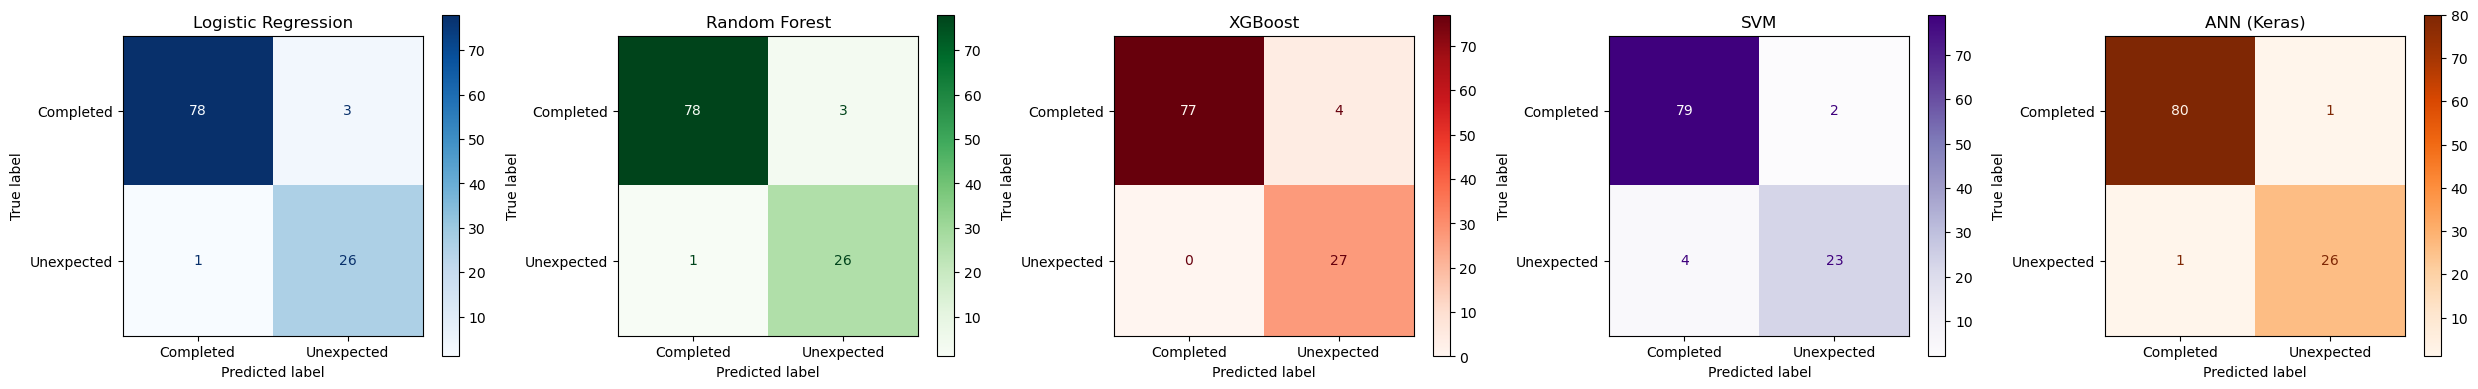

In [24]:
# ------------------------------
# CONFUSION MATRICES - ALL MODELS (PLOT WITH TITLES)
# ------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get model names
models_names = list(results_tuned.keys())
n_models = len(models_names)

# Colors for each matrix
colors = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'Greys']

# Create subplots
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))

if n_models == 1:
    axes = [axes]

# Plot confusion matrix for each model
for i, (name, ax) in enumerate(zip(models_names, axes)):
    cm = confusion_matrix(y_test, results_tuned[name]['Predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Completed', 'Unexpected'])
    disp.plot(ax=ax, cmap=colors[i % len(colors)], values_format='d')
    
    # Add title with model name and F1 Score
    ax.set_title(f'{name}', fontsize=12)

plt.tight_layout()
plt.show()

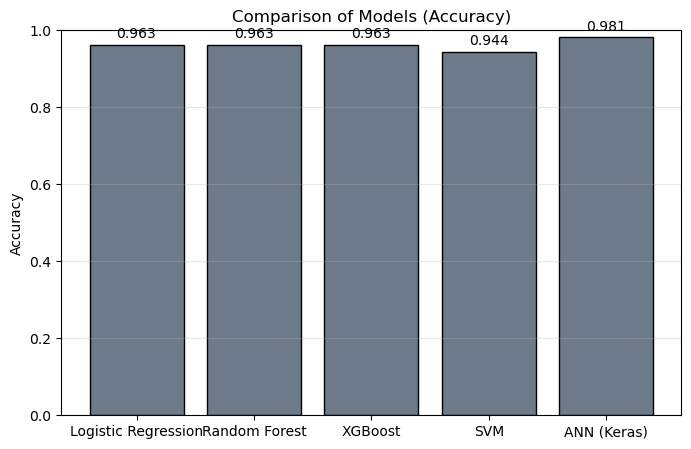

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
models_names = list(results_tuned.keys())
f1_scores = [results_tuned[name]['Accuracy'] for name in models_names]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, f1_scores, color='#6c7a89', edgecolor='black')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.title('Comparison of Models (Accuracy)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

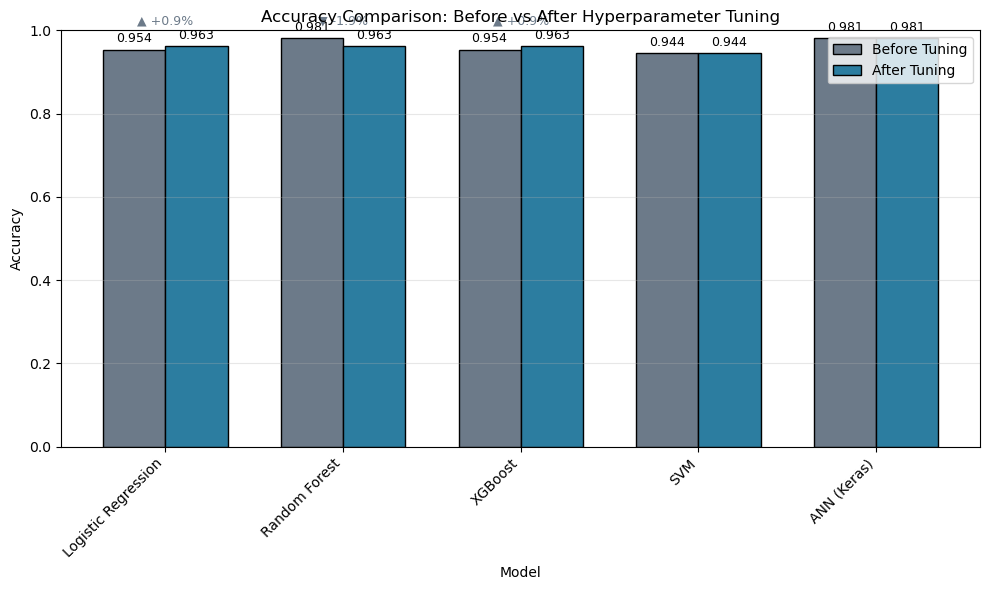


📈 IMPROVEMENT SUMMARY
Logistic Regression: 0.9537 → 0.9630
Random Forest: 0.9815 → 0.9630
XGBoost: 0.9537 → 0.9630
SVM: 0.9444 → 0.9444
ANN (Keras): 0.9815 → 0.9815


In [26]:
# ------------------------------
# COMPARISON: BEFORE vs AFTER HYPERPARAMETER TUNING
# ------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Prepare data
models_names = list(results_tuned.keys())
f1_before = []
f1_after = []

for name in models_names:
    if name in results:
        f1_before.append(results[name]['Accuracy'])
    else:
        f1_before.append(0)  # ANN not in before results
    
    f1_after.append(results_tuned[name]['Accuracy'])

# Create bar chart
x = np.arange(len(models_names))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, f1_before, width, label='Before Tuning', color='#6c7a89', edgecolor='black')
bars2 = plt.bar(x + width/2, f1_after, width, label='After Tuning', color='#2c7da0', edgecolor='black')

# Add values on top of bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Customize chart
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Before vs After Hyperparameter Tuning')
plt.xticks(x, models_names, rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add improvement percentages
for i, name in enumerate(models_names):
    if name in results:
        improvement = (f1_after[i] - f1_before[i]) * 100
        if improvement > 0:
            plt.text(i, f1_after[i] + 0.05, f'▲ +{improvement:.1f}%', 
                    ha='center', fontsize=9, color='#6c7a89')
        elif improvement < 0:
            plt.text(i, f1_after[i] + 0.05, f'▼ {improvement:.1f}%', 
                    ha='center', fontsize=9, color='#6c7a89')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("📈 IMPROVEMENT SUMMARY")
print("="*60)
for i, name in enumerate(models_names):
    if name in results:
        improvement = (f1_after[i] - f1_before[i]) * 100
        print(f"{name}: {f1_before[i]:.4f} → {f1_after[i]:.4f}")
    else:
        print(f"{name}: N/A → {f1_after[i]:.4f} (NEW MODEL)")

PermutationExplainer explainer: 109it [01:18,  1.37it/s]                                                               


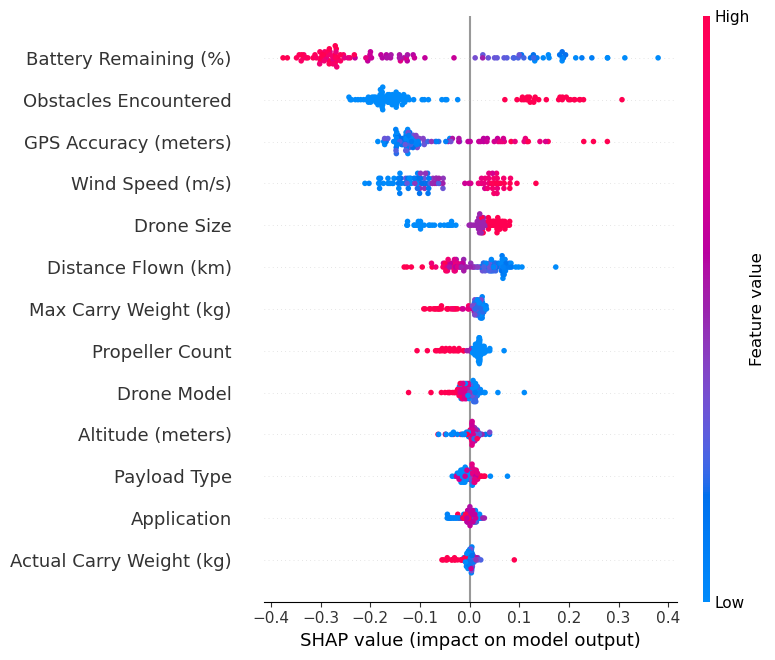

In [27]:
import shap
#  explainer (ANN)
explainer = shap.Explainer(best_model, X_train_resampled)
#  SHAP values
shap_values = explainer(X_test_scaled)
#  summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)